### Graph I

In [4]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [20]:
class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:

    state['message'] = "Heyt " + state['message'] + ", how is your day going?"
    return state

In [21]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()


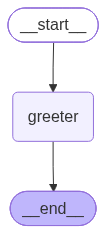

In [22]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({"message": "Bob"})

In [ ]:
result

{'message': 'Heyt Bob, how is your day going?'}

### Graph II

In [26]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

In [67]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    operation: str

def process_values(state: AgentState) -> AgentState:
    
    print(state)

    result = 0
    if state["operation"] == "*":
        result+=1
        for v in state["values"]:
            result*=v
    if state["operation"] == "+":
        for v in state["values"]:
            result+=v

    state["result"] = f"Hi there {state['name']}! Your answer = {result}"

    print(state)
    
    return state

In [68]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

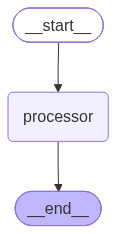

In [69]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [70]:
result = app.invoke({"values":[1, 2, 3, 4], "name": "Carlos", "operation": "+"})

{'values': [1, 2, 3, 4], 'name': 'Carlos', 'operation': '+'}
{'values': [1, 2, 3, 4], 'name': 'Carlos', 'operation': '+', 'result': 'Hi there Carlos! Your answer = 10'}


In [71]:
result['result']

'Hi there Carlos! Your answer = 10'

### Graph III

In [106]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [107]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]

    result: str

In [112]:
def first_node(state: AgentState) -> AgentState:

    state["result"] = f"{state['name']}, welcome to the system! "

    return state

def second_node(state: AgentState) -> AgentState:

    state["result"] += f"You are {state['age']} years old! "

    return state

def third_node(state: AgentState) -> AgentState:

    formatted_skills = "You have skills in: "

    total_skills = len(state['skills'])
    for i in range(total_skills):
        formatted_skills += state['skills'][i]
        if i == total_skills - 2:
            formatted_skills += " and "
        if i < total_skills - 2:
            formatted_skills += ", "

    state['result'] += formatted_skills

    return state

In [113]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.set_finish_point("second_node")
app = graph.compile()

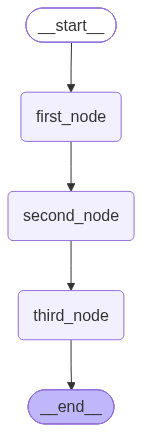

In [114]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [117]:
result = app.invoke({"name": "Carlos", "age": 22, "skills": ["Python", "FastAPI", "Vue.js"]})
result

{'name': 'Carlos',
 'age': 22,
 'skills': ['Python', 'FastAPI', 'Vue.js'],
 'result': 'Carlos, welcome to the system! You are 22 years old! You have skills in: Python, FastAPI and Vue.js'}

### Graph IV

In [118]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [89]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    result: str